In [1]:
from risk_experiment.symbolic_experiment.fit_nlc import build_model, get_data
import pymc as pm
import arviz as az

In [2]:
model_labels = [-1, 0, 1,2, 5]

traces = {}

for model_label in model_labels:
    model = build_model(model_label)

    model.build_estimation_model()

    with model.estimation_model:
        idata = az.from_netcdf(f'/data/ds-symbolicrisk/derivatives/risk_model/nlc/model{model_label}_samples.nc')
        idata = idata=idata.sel(draw=slice(None, None, 10))

        pm.compute_log_likelihood(idata)

        traces[f'Model {model_label}'] = idata

Output()

Output()

Output()

Output()

Output()

In [3]:
comparison = az.compare(traces)

/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.68 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.68 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaf

In [4]:
comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 2,0,-5376.194303,249.870998,0.000000,0.795715,70.570901,0.000000,True,log
Model -1,1,-5425.969669,174.846464,49.775367,0.104810,71.120664,13.374386,True,log
Model 1,2,-5669.451044,192.044996,293.256741,0.000000,70.184440,23.941221,True,log
Model 0,3,-5701.001090,118.023331,324.806787,0.000000,70.446908,26.450593,True,log
Model 5,4,-5795.255629,156.438184,419.061326,0.099475,74.618471,36.705548,True,log


In [7]:
comparison[['elpd_loo', 'p_loo', 'weight', 'dse']].round(2).to_clipboard()

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

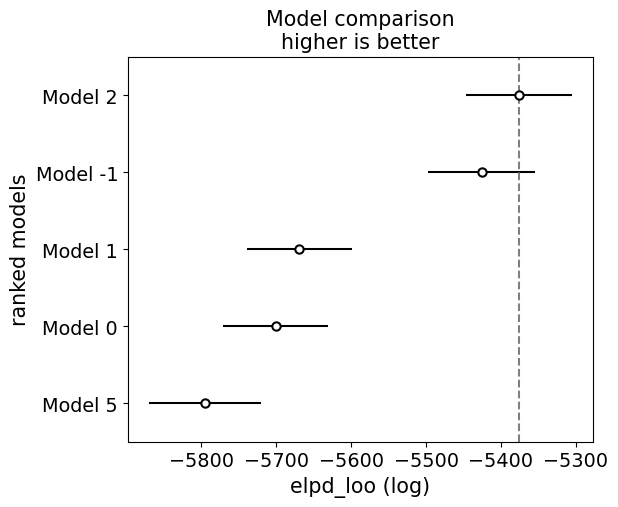

In [6]:
pm.plot_compare(comparison)